# Volatility Forecasting and Risk Modeling

This notebook consolidates the full project workflow:

1. Load train / validation / test returns  
2. Single-stock EWMA vs GARCH analysis  
3. Realized volatility comparison  
4. MAE / RMSE / QLIKE evaluation  
5. Multi-stock comparison  
6. Multi-horizon comparison  
7. EWMA lambda tuning  
8. VaR backtesting  
9. Save all charts into `results/`

## Assumed project structure

This notebook assumes the following files already exist in your repo:

- `src/models.py`
- `src/evaluation.py`
- `src/forecast.py`
- `src/tuning.py`
- `src/risk.py`
- `data/train_returns.csv`
- `data/val_returns.csv`
- `data/test_returns.csv`

If your notebook is inside `notebooks/`, this setup will work directly.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make plots look cleaner
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# Project path setup
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Data dir exists:", DATA_DIR.exists())
print("Results dir:", RESULTS_DIR)

Project root: /Users/rsinghsi/Desktop/Personal Folder/projects/VolatilityModelling
Data dir exists: True
Results dir: /Users/rsinghsi/Desktop/Personal Folder/projects/VolatilityModelling/results


In [2]:
from src.models import (
    compute_ewma_variance,
    compute_ewma_volatility,
    compute_garch_volatility
)

from src.evaluation import (
    compute_realized_volatility,
    compute_mae,
    compute_rmse,
    compute_qlike
)

from src.forecast import (
    evaluate_models_for_one_stock,
    evaluate_models_for_all_stocks,
    summarize_results,
    evaluate_models_multiple_horizons
)

from src.tuning import (
    tune_ewma_lambda_for_one_stock,
    tune_ewma_lambda_for_all_stocks,
    summarize_lambda_tuning
)

from src.risk import (
    compute_var,
    compute_var_violations
)

## Load datasets

In [3]:
train_returns = pd.read_csv(DATA_DIR / "train_returns.csv", index_col=0, parse_dates=True)
val_returns = pd.read_csv(DATA_DIR / "val_returns.csv", index_col=0, parse_dates=True)
test_returns = pd.read_csv(DATA_DIR / "test_returns.csv", index_col=0, parse_dates=True)

print("Train shape:", train_returns.shape)
print("Validation shape:", val_returns.shape)
print("Test shape:", test_returns.shape)
print("Stocks:", list(train_returns.columns))

Train shape: (1232, 25)
Validation shape: (264, 25)
Test shape: (264, 25)
Stocks: ['AAPL', 'AMD', 'AMZN', 'BA', 'BAC', 'CAT', 'COST', 'CVX', 'GOOGL', 'GS', 'HD', 'JNJ', 'JPM', 'KO', 'META', 'MSFT', 'NFLX', 'NVDA', 'PEP', 'PFE', 'PG', 'TSLA', 'UNH', 'WMT', 'XOM']


## Single-stock analysis

Choose a stock here for detailed analysis.

In [4]:
STOCK = "AAPL"
HORIZON = 5
CONFIDENCE_LEVEL = 0.95

stock_train = train_returns[STOCK].dropna()
stock_val = val_returns[STOCK].dropna()
stock_test = test_returns[STOCK].dropna()

print(f"{STOCK} train length:", len(stock_train))
print(f"{STOCK} val length:", len(stock_val))
print(f"{STOCK} test length:", len(stock_test))

AAPL train length: 1232
AAPL val length: 264
AAPL test length: 264


## EWMA volatility: daily and annualized

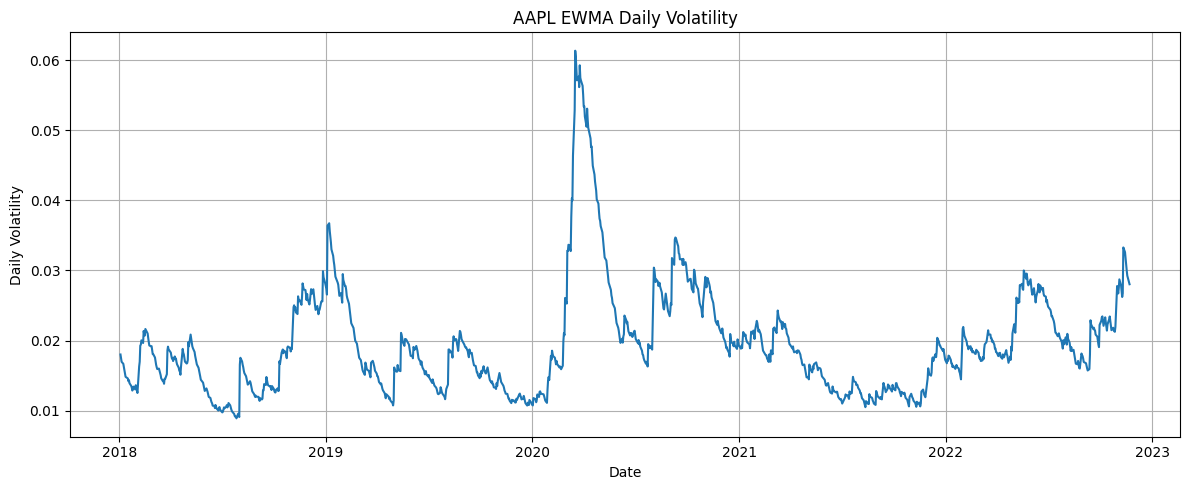

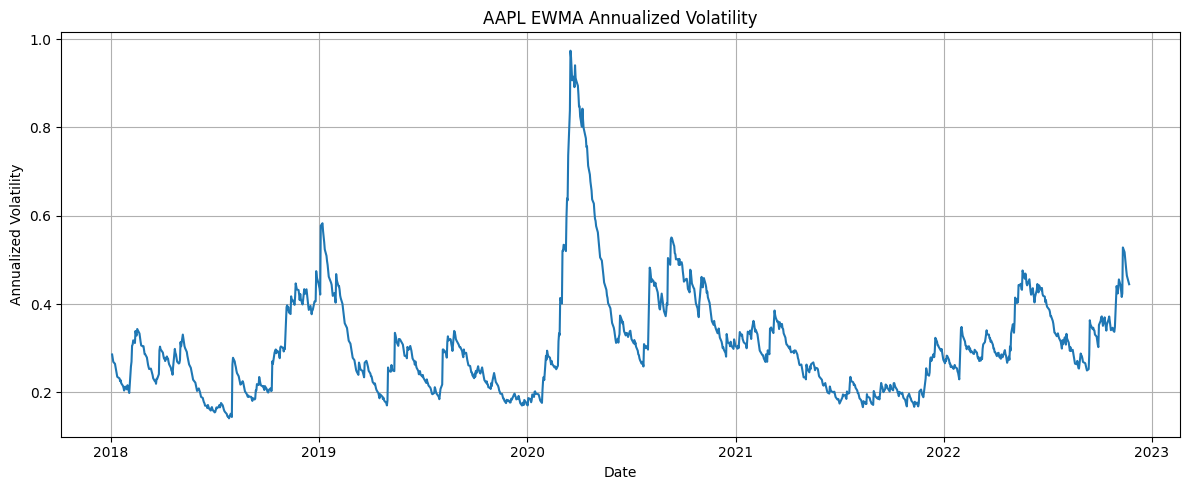

In [5]:
ewma_var = compute_ewma_variance(stock_train, lam=0.94)
ewma_vol_daily = np.sqrt(ewma_var)
ewma_vol_annual = compute_ewma_volatility(stock_train, lam=0.94, annualize=True)

fig, ax = plt.subplots()
ax.plot(ewma_vol_daily.index, ewma_vol_daily.values)
ax.set_title(f"{STOCK} EWMA Daily Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Volatility")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{STOCK.lower()}_ewma_daily_volatility.png", dpi=200)
plt.show()

fig, ax = plt.subplots()
ax.plot(ewma_vol_annual.index, ewma_vol_annual.values)
ax.set_title(f"{STOCK} EWMA Annualized Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{STOCK.lower()}_ewma_annualized_volatility.png", dpi=200)
plt.show()

## GARCH volatility

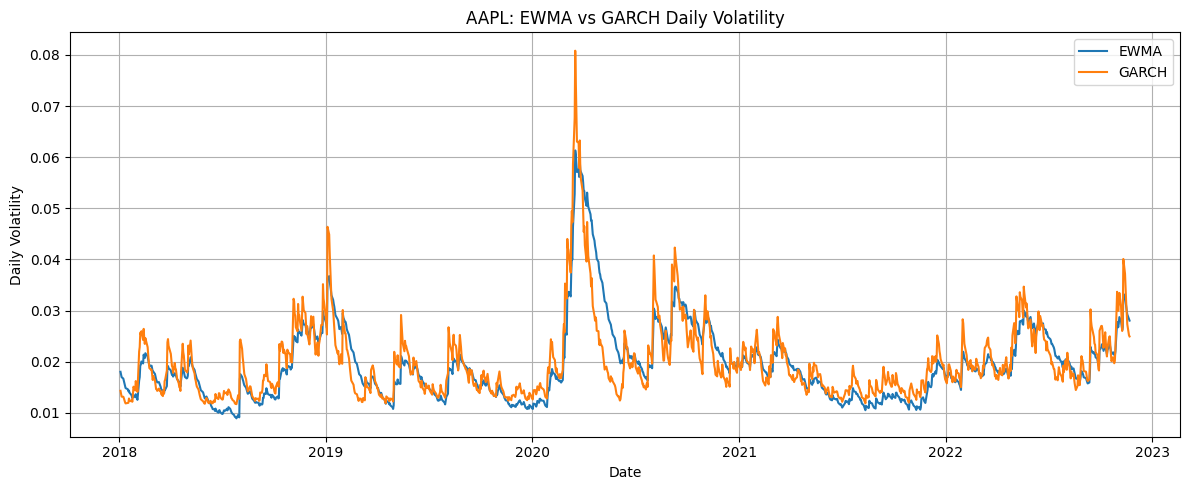

In [6]:
garch_vol_daily = compute_garch_volatility(stock_train, annualize=False)
garch_var = garch_vol_daily ** 2

fig, ax = plt.subplots()
ax.plot(ewma_vol_daily.index, ewma_vol_daily.values, label="EWMA")
ax.plot(garch_vol_daily.index, garch_vol_daily.values, label="GARCH")
ax.set_title(f"{STOCK}: EWMA vs GARCH Daily Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Volatility")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{STOCK.lower()}_ewma_vs_garch.png", dpi=200)
plt.show()

## Realized volatility comparison

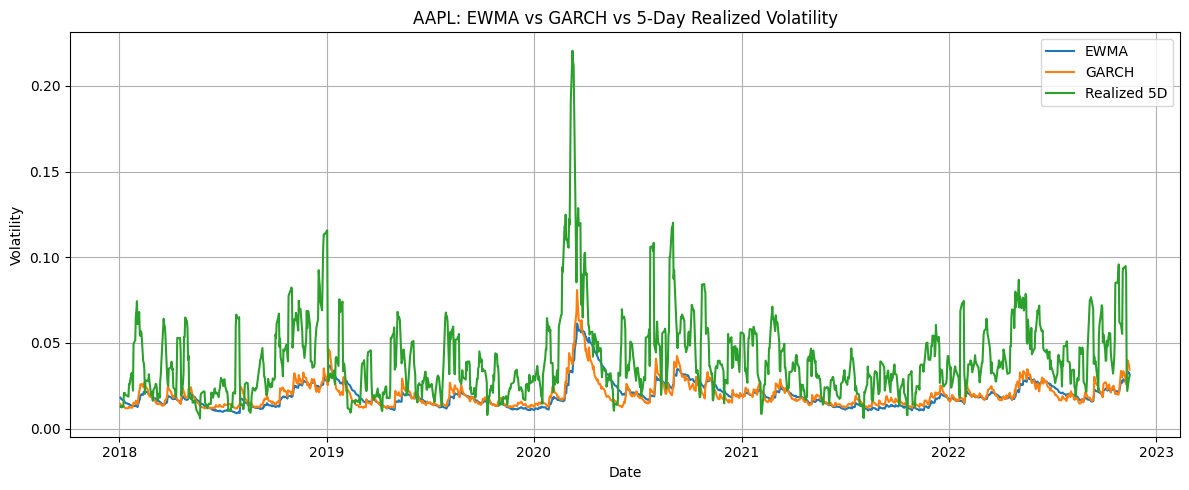

In [7]:
realized_vol_1d = compute_realized_volatility(stock_train, horizon=1, annualize=False)
realized_vol_5d = compute_realized_volatility(stock_train, horizon=5, annualize=False)
realized_vol_10d = compute_realized_volatility(stock_train, horizon=10, annualize=False)

comparison_5d = pd.concat(
    [ewma_vol_daily, garch_vol_daily, realized_vol_5d],
    axis=1
).dropna()

comparison_5d.columns = ["EWMA", "GARCH", "Realized_5D"]

fig, ax = plt.subplots()
ax.plot(comparison_5d.index, comparison_5d["EWMA"], label="EWMA")
ax.plot(comparison_5d.index, comparison_5d["GARCH"], label="GARCH")
ax.plot(comparison_5d.index, comparison_5d["Realized_5D"], label="Realized 5D")
ax.set_title(f"{STOCK}: EWMA vs GARCH vs 5-Day Realized Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{STOCK.lower()}_realized_vol_comparison_5d.png", dpi=200)
plt.show()

## Single-stock metrics

In [8]:
single_stock_metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "QLIKE"],
    "EWMA": [
        compute_mae(ewma_vol_daily, realized_vol_5d),
        compute_rmse(ewma_vol_daily, realized_vol_5d),
        compute_qlike(ewma_var, realized_vol_5d)
    ],
    "GARCH": [
        compute_mae(garch_vol_daily, realized_vol_5d),
        compute_rmse(garch_vol_daily, realized_vol_5d),
        compute_qlike(garch_var, realized_vol_5d)
    ]
})

single_stock_metrics["GARCH_Better"] = single_stock_metrics["GARCH"] < single_stock_metrics["EWMA"]
single_stock_metrics

,Metric,EWMA,GARCH,GARCH_Better
0,MAE,0.022093,0.021520,True
1,RMSE,0.030305,0.029476,True
2,QLIKE,3.572942,2.998445,True


## Full multi-stock comparison (fixed EWMA lambda = 0.94)

In [9]:
all_results_5d = evaluate_models_for_all_stocks(
    train_returns,
    horizon=5,
    ewma_lambda=0.94
)

all_results_5d = all_results_5d.sort_values("stock").reset_index(drop=True)
all_results_5d

,stock,ewma_mae,ewma_rmse,ewma_qlike,garch_mae,garch_rmse,garch_qlike,mae_improvement,rmse_improvement,qlike_improvement,garch_better_mae,garch_better_rmse,garch_better_qlike
0,AAPL,0.022093,0.030305,3.572942,0.021520,0.029476,2.998445,0.000573,0.000829,0.574498,True,True,True
1,AMD,0.038372,0.050592,3.479271,0.037359,0.050076,2.921837,0.001014,0.000516,0.557434,True,True,True
2,AMZN,0.023562,0.032424,3.700435,0.022955,0.031920,3.093787,0.000608,0.000505,0.606648,True,True,True
3,BA,0.030227,0.047587,3.762146,0.029865,0.047330,3.165265,0.000362,0.000257,0.596882,True,True,True
4,BAC,0.021731,0.032614,3.798910,0.021714,0.032298,3.207840,0.000017,0.000317,0.591069,True,True,True
5,CAT,0.022557,0.030137,3.502249,0.022098,0.029839,2.923208,0.000458,0.000298,0.579041,True,True,True
6,COST,0.015474,0.022401,3.935599,0.014887,0.021821,3.139789,0.000588,0.000580,0.795810,True,True,True
7,CVX,0.020788,0.033824,3.733898,0.020556,0.033001,3.015955,0.000231,0.000823,0.717943,True,True,True
8,GOOGL,0.020708,0.028451,3.845046,0.020252,0.028137,3.013631,0.000455,0.000315,0.831415,True,True,True
9,GS,0.020702,0.030616,3.488947,0.020443,0.030332,3.011604,0.000259,0.000285,0.477342,True,True,True


In [10]:
summary_5d = summarize_results(all_results_5d)
summary_5d

num_stocks                  25.000000
avg_ewma_mae                 0.022045
avg_garch_mae                0.021498
avg_ewma_rmse                0.032372
avg_garch_rmse               0.031852
avg_ewma_qlike               3.906059
avg_garch_qlike              3.108620
garch_better_mae_count      25.000000
garch_better_rmse_count     24.000000
garch_better_qlike_count    25.000000
dtype: float64

## Top QLIKE improvements

In [11]:
top_qlike_improvements = all_results_5d.sort_values("qlike_improvement", ascending=False).reset_index(drop=True)
top_qlike_improvements.head(10)

,stock,ewma_mae,ewma_rmse,ewma_qlike,garch_mae,garch_rmse,garch_qlike,mae_improvement,rmse_improvement,qlike_improvement,garch_better_mae,garch_better_rmse,garch_better_qlike
0,NFLX,0.029910,0.047443,4.915771,0.027868,0.046084,3.106154,0.002042,0.001359,1.809618,True,True,True
1,META,0.027271,0.043812,5.374686,0.025757,0.042572,3.581218,0.001514,0.001239,1.793468,True,True,True
2,WMT,0.014248,0.023367,4.863760,0.013537,0.022822,3.389741,0.000710,0.000545,1.474019,True,True,True
3,KO,0.013180,0.020198,4.130848,0.012841,0.020207,3.066050,0.000339,-0.000009,1.064798,True,False,True
4,JNJ,0.012945,0.019719,3.998027,0.012640,0.019559,3.027343,0.000305,0.000160,0.970684,True,True,True
5,TSLA,0.043279,0.059160,3.912157,0.042113,0.058785,3.064044,0.001166,0.000375,0.848112,True,True,True
6,PG,0.013379,0.020760,3.938072,0.013132,0.020206,3.101797,0.000247,0.000554,0.836275,True,True,True
7,GOOGL,0.020708,0.028451,3.845046,0.020252,0.028137,3.013631,0.000455,0.000315,0.831415,True,True,True
8,HD,0.017328,0.027711,3.900321,0.016924,0.027075,3.074937,0.000404,0.000635,0.825384,True,True,True
9,COST,0.015474,0.022401,3.935599,0.014887,0.021821,3.139789,0.000588,0.000580,0.795810,True,True,True


## Multi-horizon analysis

In [12]:
multi_results = evaluate_models_multiple_horizons(
    train_returns,
    horizons=[1, 5, 10]
)

summary_by_horizon = multi_results.groupby("horizon").agg({
    "ewma_mae": "mean",
    "garch_mae": "mean",
    "ewma_rmse": "mean",
    "garch_rmse": "mean",
    "ewma_qlike": "mean",
    "garch_qlike": "mean",
    "garch_better_qlike": "sum"
})

summary_by_horizon

Running for horizon = 1
Running for horizon = 5
Running for horizon = 10


,ewma_mae,garch_mae,ewma_rmse,garch_rmse,ewma_qlike,garch_qlike,garch_better_qlike
horizon,,,,,,,
1,0.011976,0.012115,0.016380,0.016077,1.662419,1.596292,25
5,0.022045,0.021498,0.032372,0.031852,3.906059,3.108620,25
10,0.040302,0.039731,0.051639,0.051110,9.840970,7.947939,25


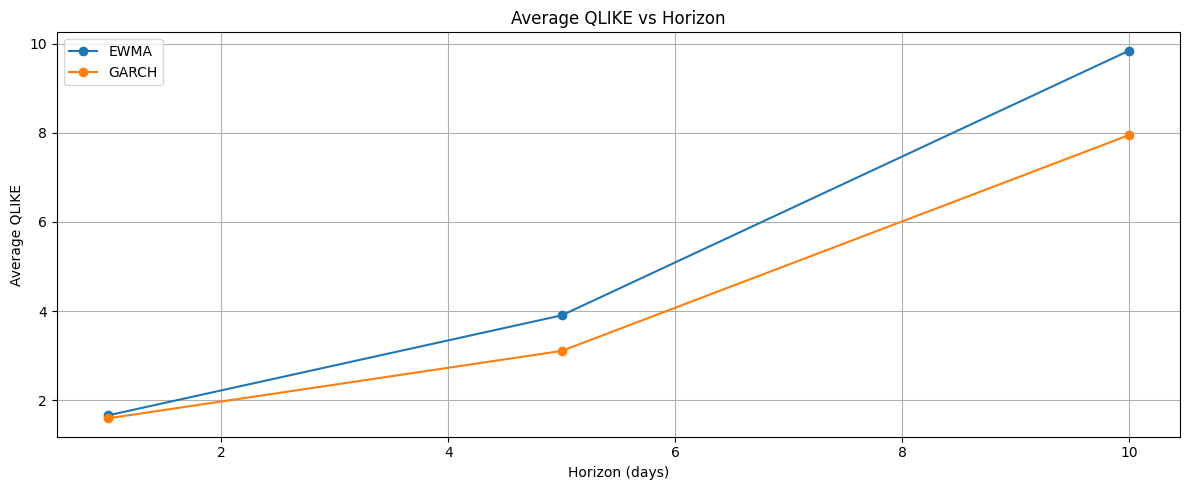

In [13]:
fig, ax = plt.subplots()
ax.plot(summary_by_horizon.index, summary_by_horizon["ewma_qlike"], marker="o", label="EWMA")
ax.plot(summary_by_horizon.index, summary_by_horizon["garch_qlike"], marker="o", label="GARCH")
ax.set_title("Average QLIKE vs Horizon")
ax.set_xlabel("Horizon (days)")
ax.set_ylabel("Average QLIKE")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "average_qlike_vs_horizon.png", dpi=200)
plt.show()

## EWMA lambda tuning on validation set

In [14]:
lambda_grid = [0.90, 0.92, 0.94, 0.96, 0.98]

best_lambda_single, lambda_results_single = tune_ewma_lambda_for_one_stock(
    val_returns[STOCK],
    lambdas=lambda_grid,
    horizon=5
)

print(f"Best lambda for {STOCK}:", best_lambda_single)
lambda_results_single

Best lambda for AAPL: 0.98


,lambda,qlike
0,0.98,1.823277
1,0.96,2.369400
2,0.94,2.674193
3,0.92,2.901489
4,0.90,3.092441


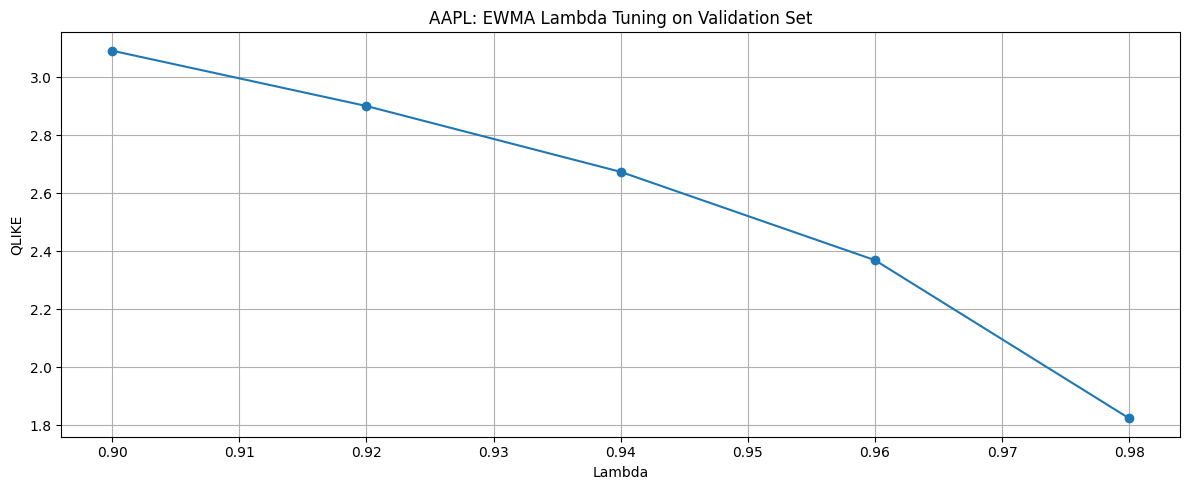

In [15]:
fig, ax = plt.subplots()
ax.plot(lambda_results_single["lambda"], lambda_results_single["qlike"], marker="o")
ax.set_title(f"{STOCK}: EWMA Lambda Tuning on Validation Set")
ax.set_xlabel("Lambda")
ax.set_ylabel("QLIKE")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{STOCK.lower()}_lambda_tuning.png", dpi=200)
plt.show()

In [16]:
all_lambda_results = tune_ewma_lambda_for_all_stocks(
    val_returns,
    lambdas=lambda_grid,
    horizon=5
)

all_lambda_results

,stock,best_lambda,best_qlike
0,AAPL,0.98,1.823277
1,AMD,0.98,2.972981
2,AMZN,0.98,2.692809
3,BA,0.98,2.349083
4,BAC,0.98,3.100828
5,CAT,0.98,3.559090
6,COST,0.98,1.774195
7,CVX,0.98,2.737370
8,GOOGL,0.98,3.011190
9,GS,0.98,3.209782


In [17]:
lambda_summary = summarize_lambda_tuning(all_lambda_results)
lambda_summary

num_stocks            25.0000
avg_best_lambda        0.9792
median_best_lambda     0.9800
min_best_lambda        0.9600
max_best_lambda        0.9800
dtype: float64

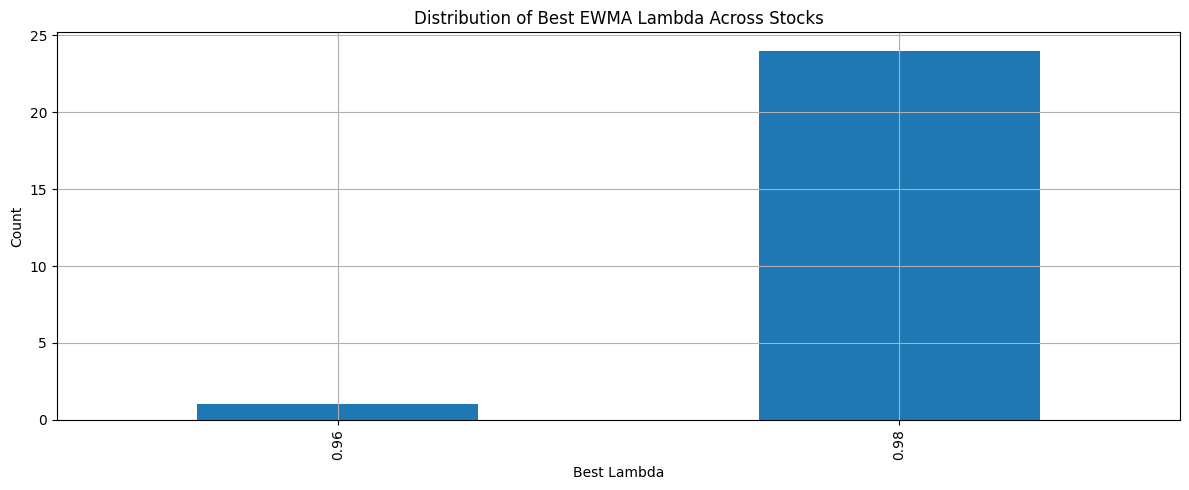

In [18]:
fig, ax = plt.subplots()
all_lambda_results["best_lambda"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Distribution of Best EWMA Lambda Across Stocks")
ax.set_xlabel("Best Lambda")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "best_lambda_distribution.png", dpi=200)
plt.show()

## VaR backtesting for single stock

In [19]:
var_ewma = compute_var(ewma_vol_daily, confidence_level=CONFIDENCE_LEVEL)
var_garch = compute_var(garch_vol_daily, confidence_level=CONFIDENCE_LEVEL)

ewma_violation_rate = compute_var_violations(stock_train, var_ewma)
garch_violation_rate = compute_var_violations(stock_train, var_garch)

var_summary = pd.DataFrame({
    "Model": ["EWMA", "GARCH"],
    "VaR_Violation_Rate": [ewma_violation_rate, garch_violation_rate],
    "Target_Rate": [1 - CONFIDENCE_LEVEL, 1 - CONFIDENCE_LEVEL]
})

var_summary

,Model,VaR_Violation_Rate,Target_Rate
0,EWMA,0.052760,0.05
1,GARCH,0.046266,0.05


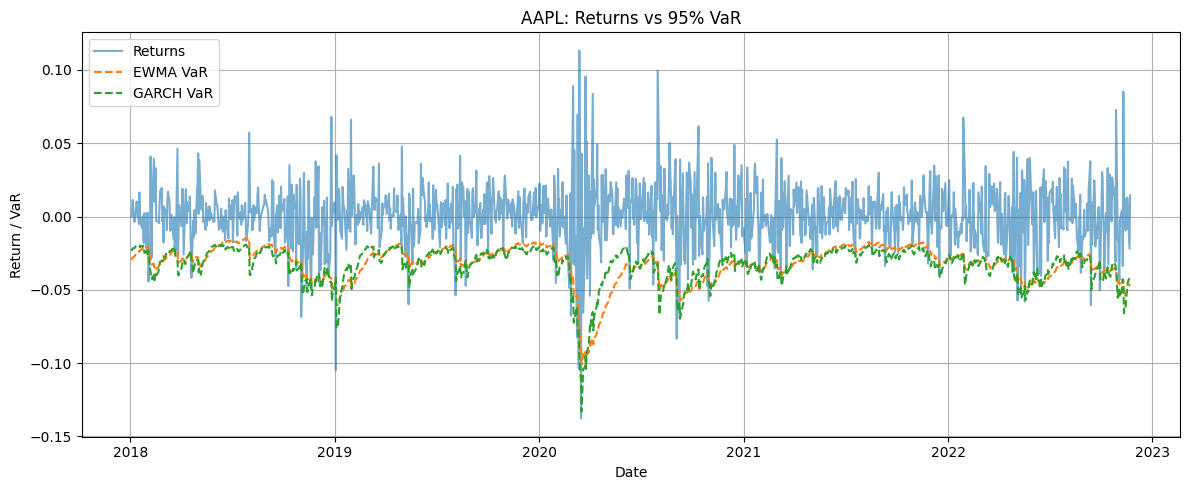

In [20]:
fig, ax = plt.subplots()
ax.plot(stock_train.index, stock_train.values, label="Returns", alpha=0.6)
ax.plot(var_ewma.index, var_ewma.values, label="EWMA VaR", linestyle="--")
ax.plot(var_garch.index, var_garch.values, label="GARCH VaR", linestyle="--")
ax.set_title(f"{STOCK}: Returns vs 95% VaR")
ax.set_xlabel("Date")
ax.set_ylabel("Return / VaR")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{STOCK.lower()}_var_backtest.png", dpi=200)
plt.show()

## Compact final summary

In [21]:
final_summary = {
    "single_stock": STOCK,
    "fixed_lambda": 0.94,
    "best_lambda_for_single_stock": best_lambda_single,
    "avg_ewma_qlike_5d": float(summary_5d["avg_ewma_qlike"]),
    "avg_garch_qlike_5d": float(summary_5d["avg_garch_qlike"]),
    "garch_better_qlike_count_5d": int(summary_5d["garch_better_qlike_count"]),
    "ewma_var_violation_rate": float(ewma_violation_rate),
    "garch_var_violation_rate": float(garch_violation_rate),
}
pd.Series(final_summary)

single_stock                        AAPL
fixed_lambda                        0.94
best_lambda_for_single_stock        0.98
avg_ewma_qlike_5d               3.906059
avg_garch_qlike_5d               3.10862
garch_better_qlike_count_5d           25
ewma_var_violation_rate          0.05276
garch_var_violation_rate        0.046266
dtype: object

## Files generated in `results/`

This notebook saves charts into the `results/` directory. You can inspect the folder at the end.

In [22]:
sorted([p.name for p in RESULTS_DIR.iterdir()])

['aapl_ewma_annualized_volatility.png',
 'aapl_ewma_daily_volatility.png',
 'aapl_ewma_vs_garch.png',
 'aapl_lambda_tuning.png',
 'aapl_realized_vol_comparison_5d.png',
 'aapl_var_backtest.png',
 'average_qlike_vs_horizon.png',
 'best_lambda_distribution.png']